# Velocity Comparison (MultiVelo)
After computing the RNA velocities per cell using also the ATAC data, the cells are split into two cohorts, based on accessibility of different transcription factor motifs. The velocities of cells that are close in the RNA space, but far apart for this one transcription factor are compared.

1. Plotting the velocities of different cell cohorts
2. Computing a simple average trajectory for a subset of certain cell cohorts
3. Computing angle differences between nearest neighbors in RNA space (comparing spliced, unspliced and chrom velocities)
4. Comparing magnitude of velocities / push towards differentiation

For the final point, look into throwing out cells marked as MPPs but very far from the main MPP cluster

In [10]:
import scanpy as sc
import numpy as np 
import matplotlib.pyplot as plt
import multivelo as mv
import pandas as pd
import scvelo as scv
from pathlib import Path
from scipy.spatial.distance import cdist, euclidean
from scipy.optimize import linear_sum_assignment
import seaborn as sns

In [2]:
python_data_dir = r"C:\Users\Nikla\Documents\MoBi_Master_FS.3\Internship AG Höfer\DynaVelo_testing\data"
mv_data = sc.read_h5ad(rf"{python_data_dir}\multivelo_results.h5ad")
adata_atac = sc.read_h5ad(fr"{python_data_dir}\all_atac_aggregated_peaks.h5ad")

In [3]:
adata_atac = adata_atac[mv_data.obs_names, mv_data.var_names]
nn_idx = np.loadtxt(rf"{python_data_dir}/nn_idx.txt", delimiter=',')
nn_dist = np.loadtxt(rf"{python_data_dir}/nn_dist.txt", delimiter=',')
mv.knn_smooth_chrom(adata_atac, nn_idx, nn_dist)

In [4]:
z_scores = sc.read_h5ad(rf"{python_data_dir}\z_scores_raw.h5ad")
z_scores.obs_names = [i[9:-2] for i in z_scores.obs_names.values]
intersect_cells = np.intersect1d(adata_atac.obs_names, z_scores.obs_names)

adata_atac = adata_atac[intersect_cells,:]
z_scores = z_scores[intersect_cells,:]
mv_data = mv_data[intersect_cells,:]

In [5]:
mv_data

View of AnnData object with n_obs × n_vars = 5241 × 940
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'S.Score', 'G2M.Score', 'Phase', 'SCT_snn_res.0.8', 'seurat_clusters', 'doublets_normal_cluster_based', 'doublets_random', 'doublets_RNA_consensus', 'nCount_SCT_no_regression', 'nFeature_SCT_no_regression', 'tricyclePosition', 'Phase_tricycle', 'tricycle_fine', 'cell_cycle_atac_classification', 'PromoterPercent', 'immunophenotype_predicted', 'predicted.id', 'prediction.score.LT', 'prediction.score.ST', 'prediction.score.MPP', 'prediction.score.LS_K', 'prediction.score.max', 'Identity_for_diff_testing', 'RF_prediction', 'angle_degree', 'immunophenotype_predicted_cleaned', 'HSC.promoters', 'LMPP.promoters', 'myeloid.promoters', 'MEP.promoters', '

## Comaprison

In [5]:
scv.settings.verbosity = 3
scv.settings.presenter_view = True
scv.set_figure_params('scvelo')
scv.settings.figdir = rf"{python_data_dir}\multivelo_comparison"
scv.settings.plot_prefix = ""
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
np.set_printoptions(suppress=True)

In [6]:
mv.velocity_graph(mv_data)
mv.latent_time(mv_data)

computing velocity graph (using 1/8 cores)


  0%|          | 0/5241 [00:00<?, ?cells/s]

    finished (0:00:32) --> added 
    'velo_s_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 0 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:01) --> added 
    'latent_time', shared time (adata.obs)


computing velocity embedding
    finished (0:00:01) --> added
    'velo_s_norm_umap', embedded velocity vectors (adata.obsm)


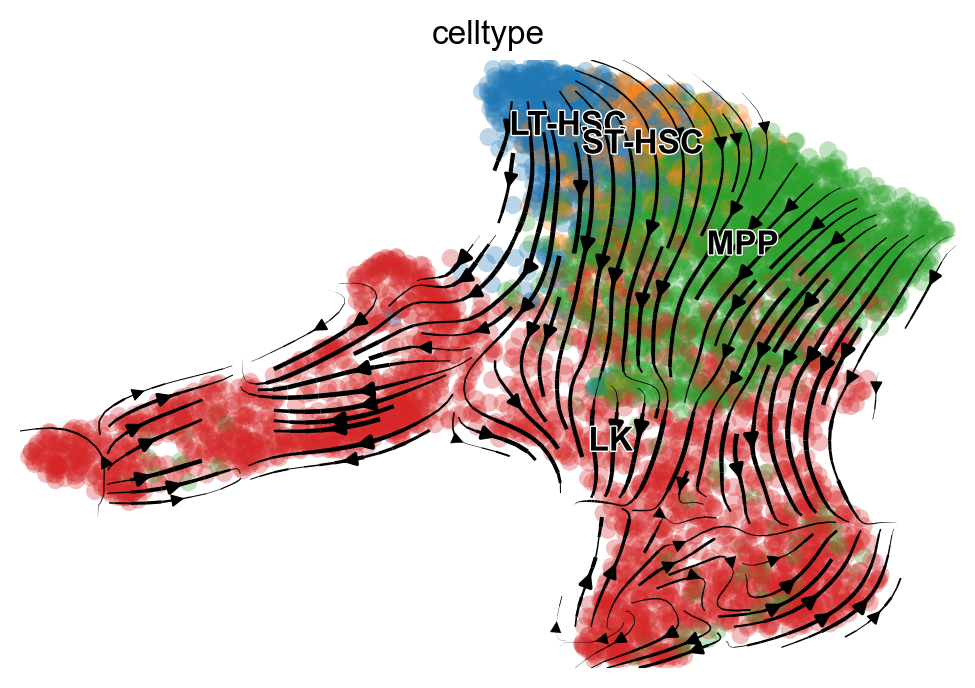

In [7]:
mv.velocity_embedding_stream(mv_data, basis='umap', color='celltype')

In [8]:
tfs = ["HOXA9", "SPI1", "CEBPA", "GATA1", "GATA2", "MYC"]

for i, tf in enumerate(tfs): 

    tf_data = z_scores[:, tf].X.flatten()

    labels = pd.qcut(
        tf_data,
        q=[0, 0.25, 0.75, 1.0],  
        labels=["low", "med", "high"],
    )

    mv_data.obs[f"{tf}_zscore"] = pd.Series(labels, index=z_scores.obs_names).reindex(mv_data.obs_names)

In [8]:
assert (z_scores.obs_names == mv_data.obs_names).all

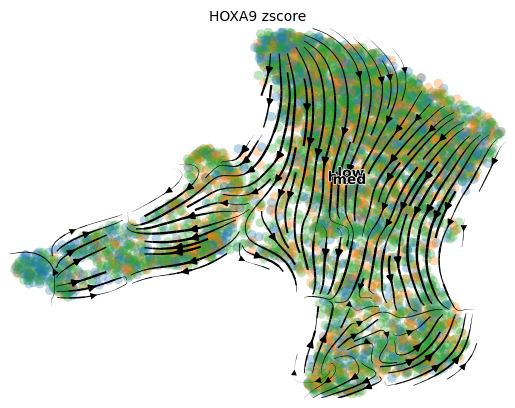

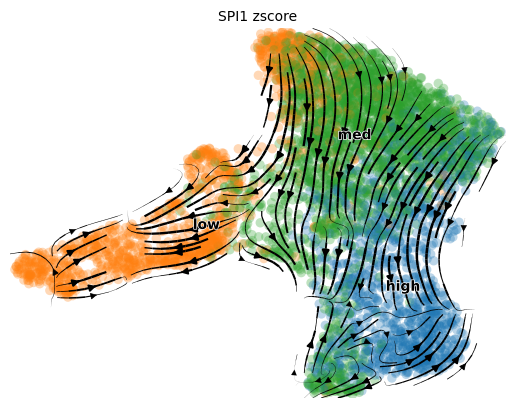

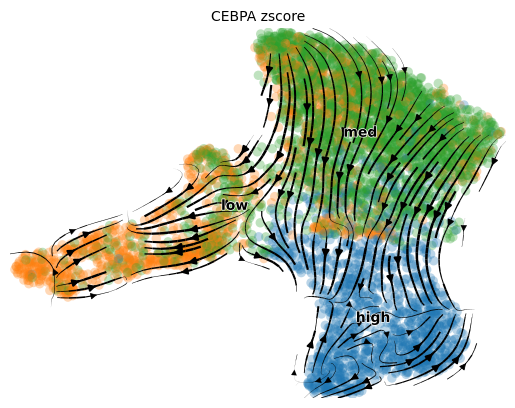

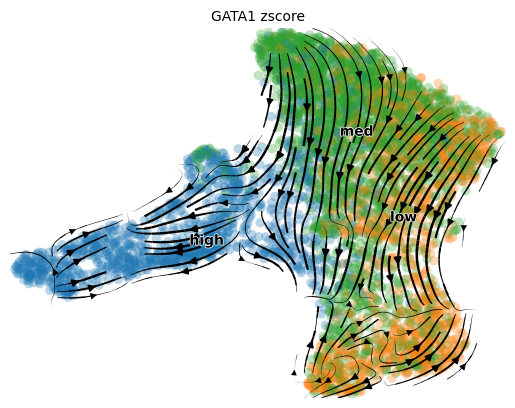

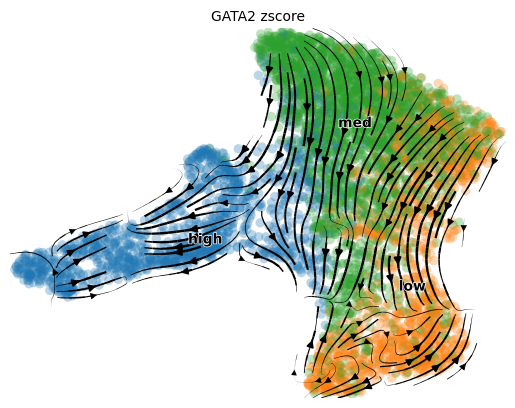

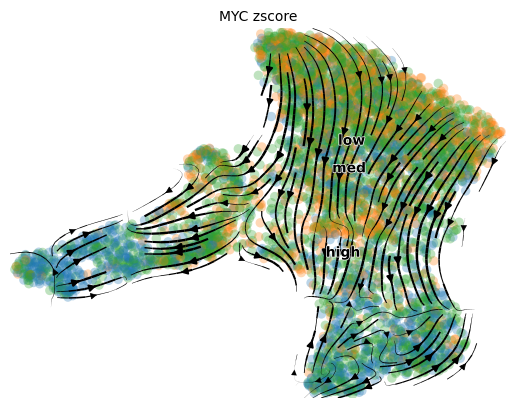

In [ ]:
for i, tf in enumerate(tfs): 
    mv.velocity_embedding_stream(
        mv_data, 
        basis='umap', 
        color=f"{tf}_zscore",
    )

In [19]:
for tf in tfs:
    zscore = mv_data.obs[f"{tf}_zscore"]
    celltype = mv_data.obs["celltype"]

    cond_non_mpp = celltype != "MPP"
    cond_med = zscore == "med"
    cond_high_mpp = (celltype == "MPP") & (zscore == "high")
    cond_low_mpp = (celltype == "MPP") & (zscore == "low")

    conditions = [cond_non_mpp, cond_med, cond_high_mpp, cond_low_mpp]
    choices = ["non-MPP", "med", "high_mpp", "low_mpp"]

    mv_data.obs[f"{tf}_zscore_mpp"] = np.select(
        conditions, choices, default="other"
    )

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/HOXA9_high_mpp.png


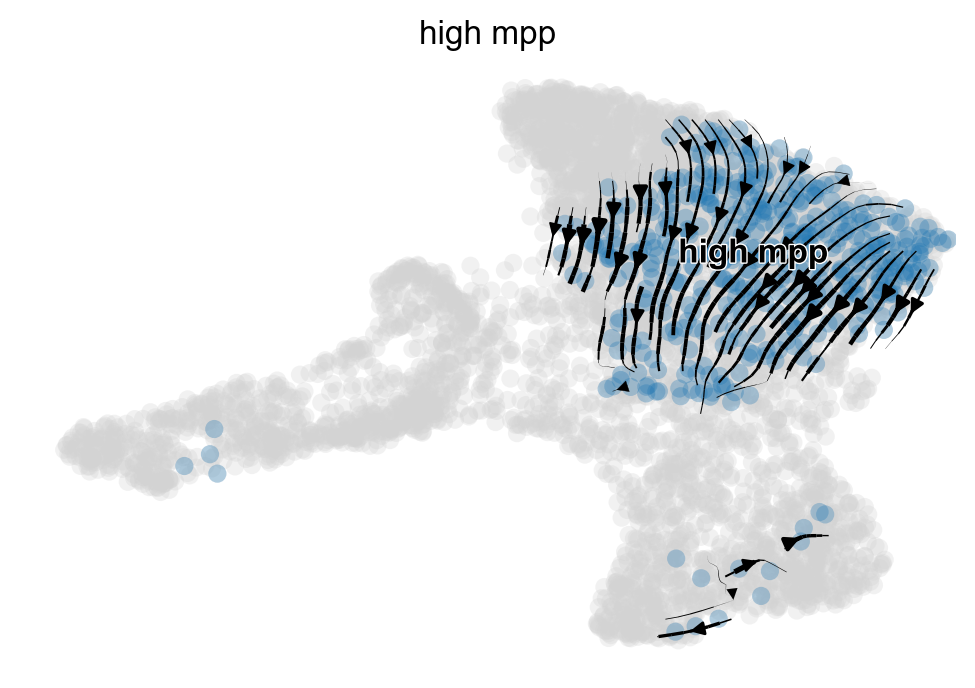

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/HOXA9_low_mpp.png


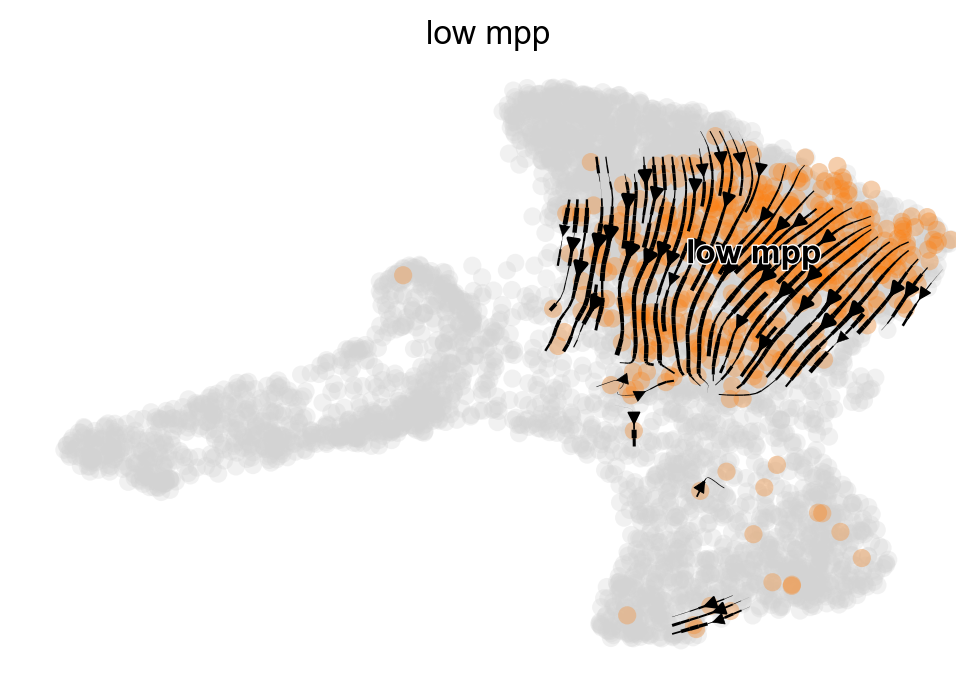

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/SPI1_high_mpp.png


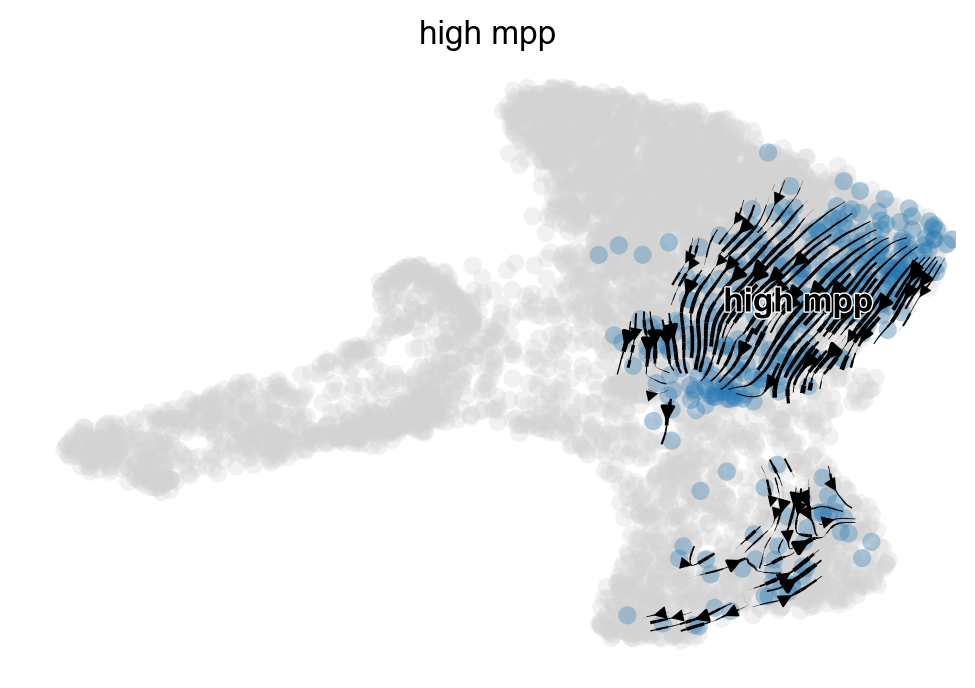

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/SPI1_low_mpp.png


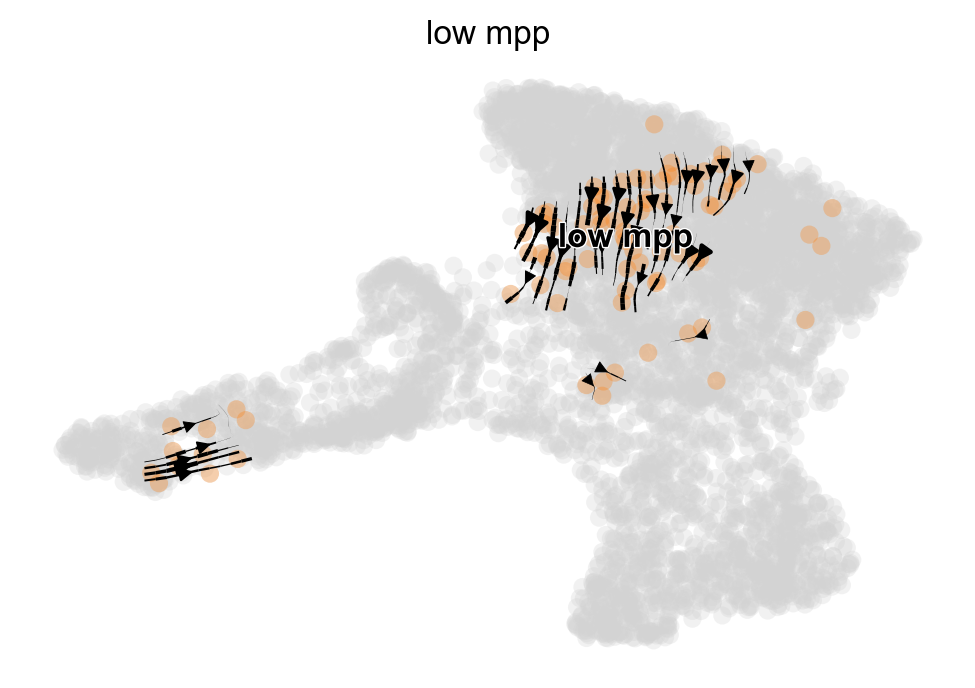

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/CEBPA_high_mpp.png


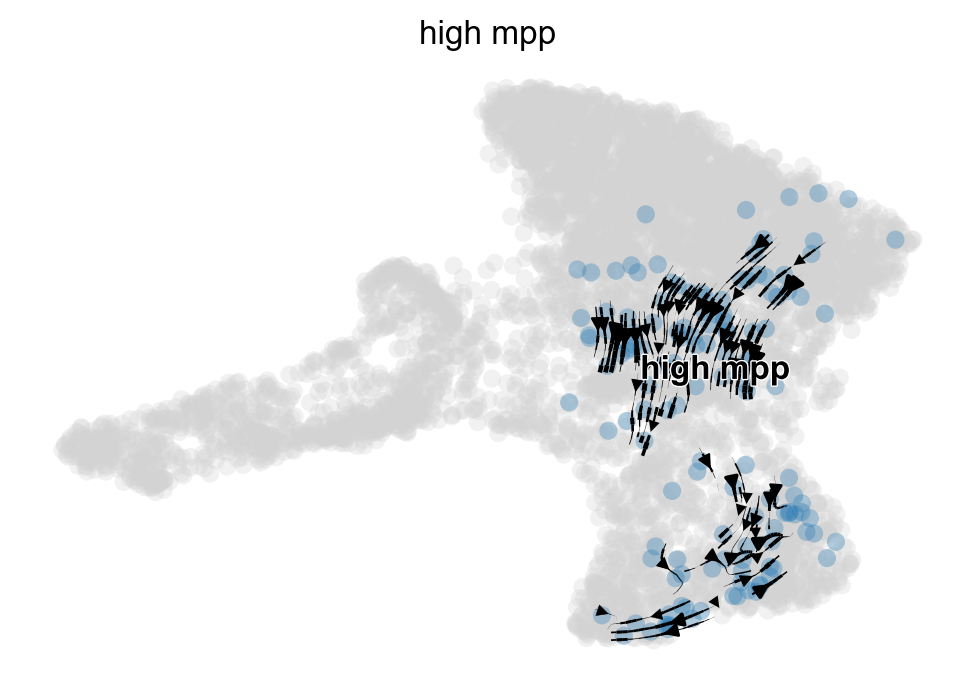

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/CEBPA_low_mpp.png


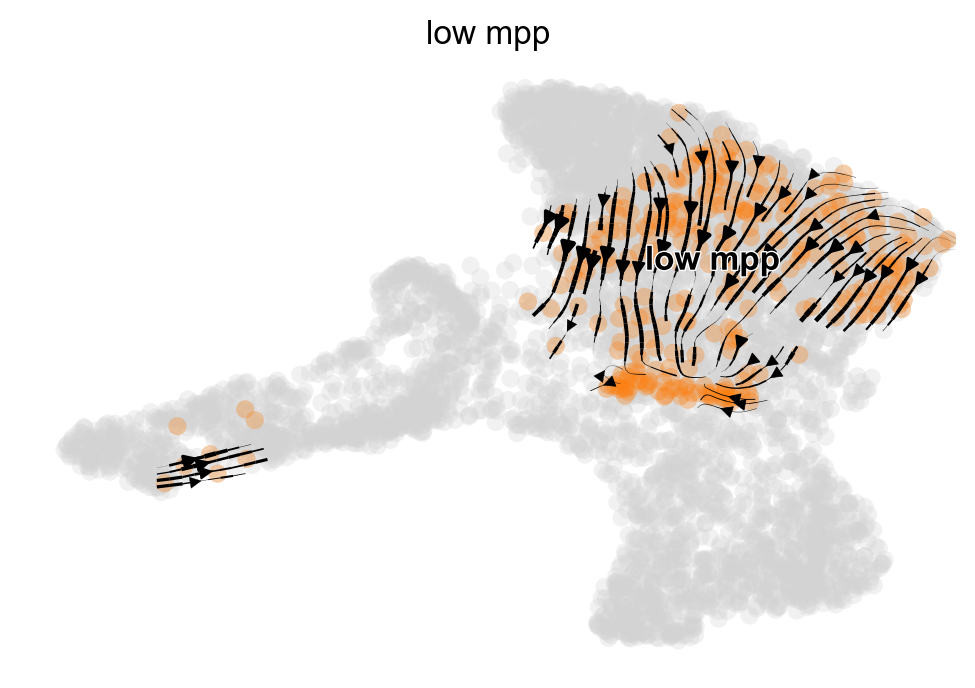

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/GATA1_high_mpp.png


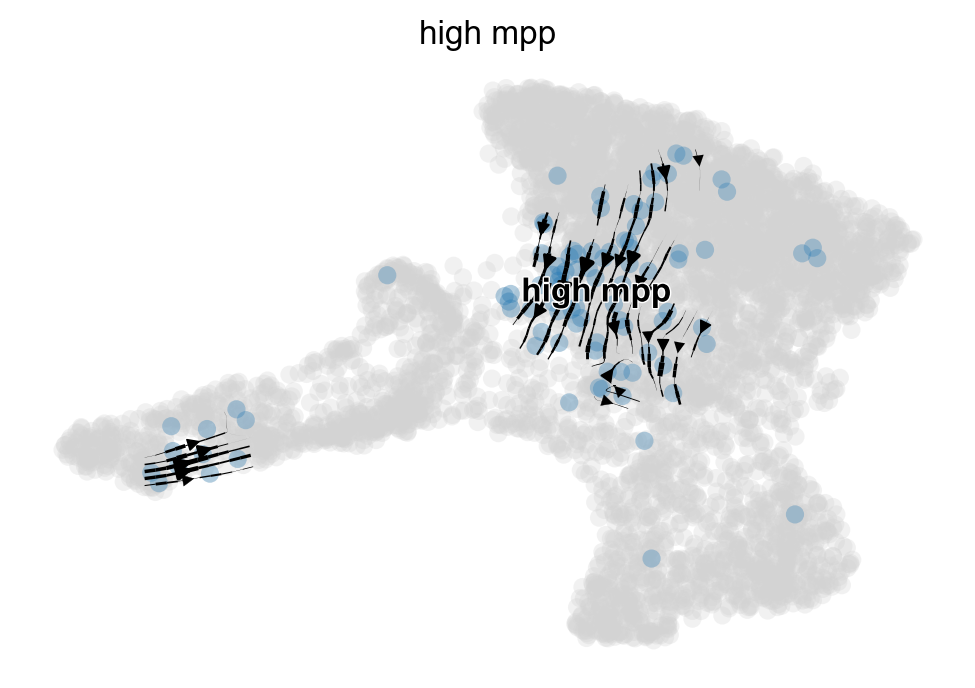

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/GATA1_low_mpp.png


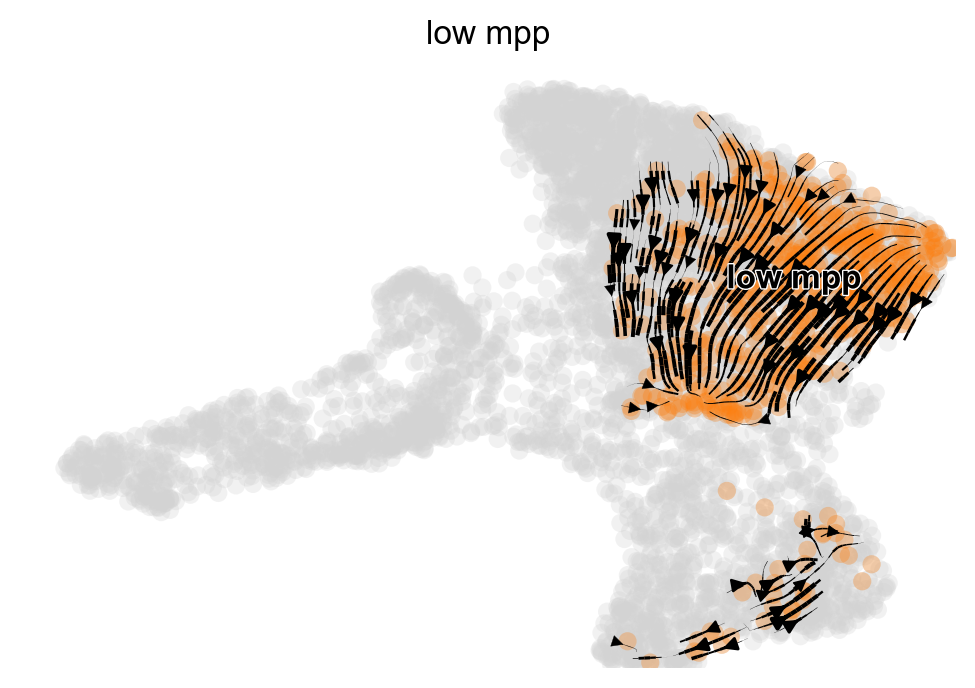

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/GATA2_high_mpp.png


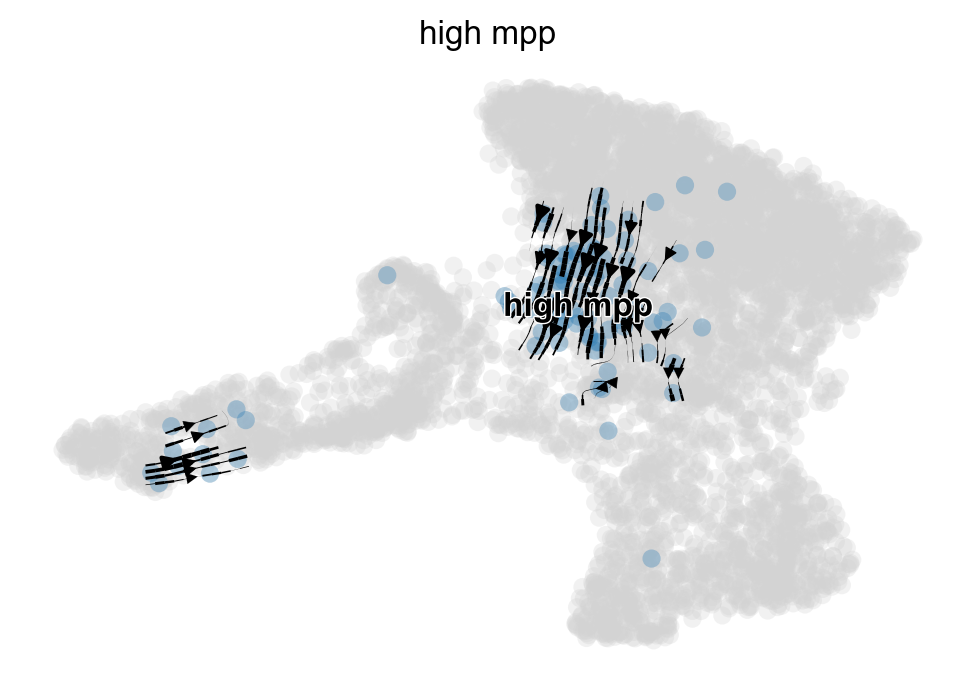

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/GATA2_low_mpp.png


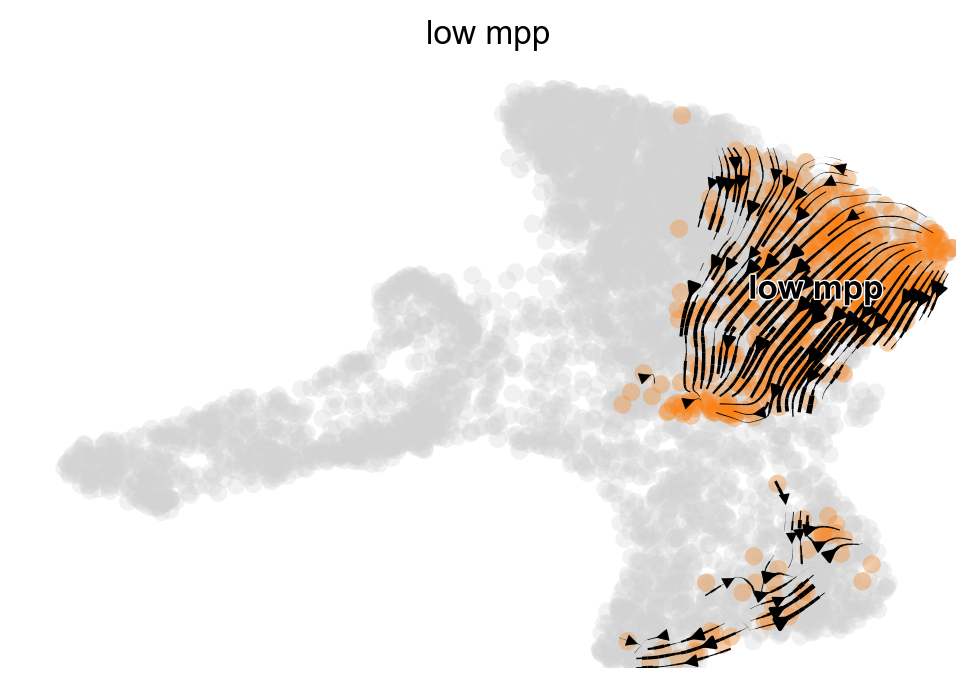

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/MYC_high_mpp.png


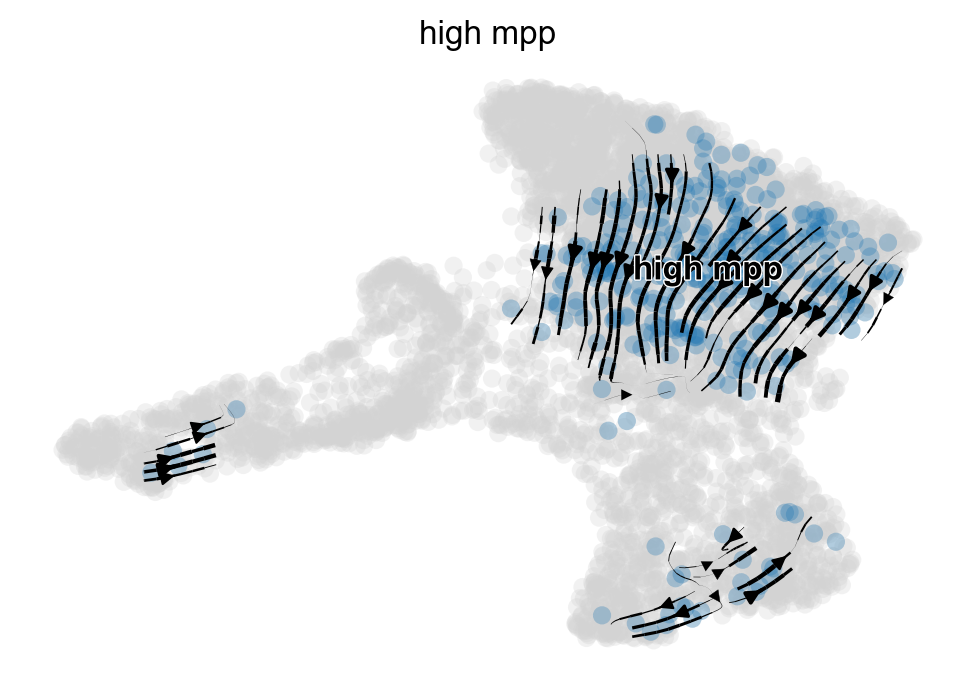

saving figure to file C:/Users/Nikla/Documents/MoBi_Master_FS.3/Internship AG Höfer/DynaVelo_testing/data/multivelo_comparison/MYC_low_mpp.png


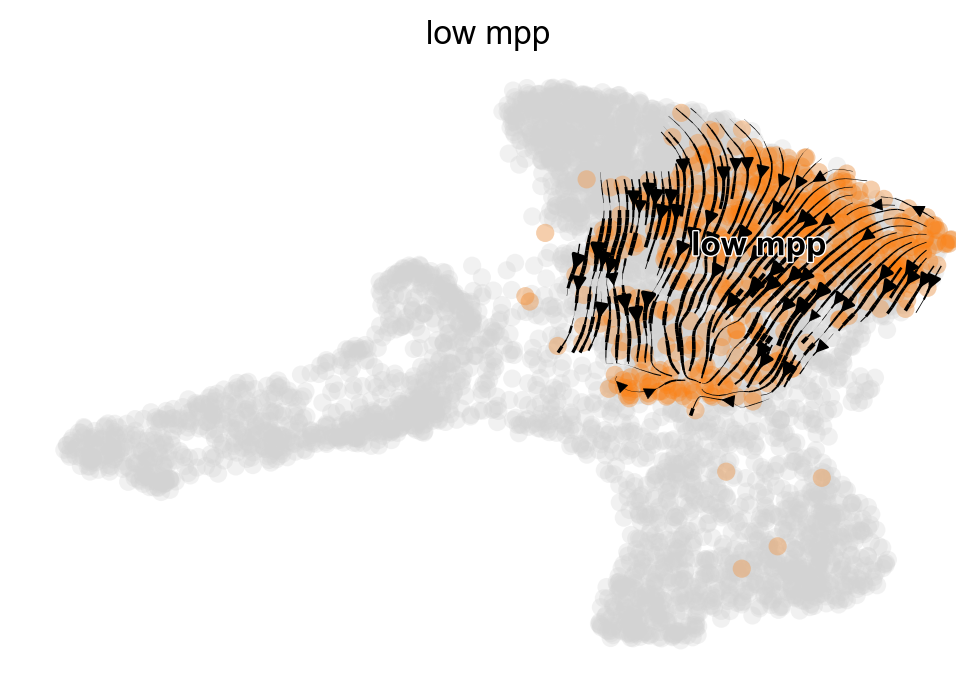

In [36]:
save_dir = Path(r"C:\Users\Nikla\Documents\MoBi_Master_FS.3\Internship AG Höfer\DynaVelo_testing\data\multivelo_comparison")

for tf in tfs:
    col = f"{tf}_zscore_mpp"

    save_path_high = (save_dir / f"{tf}_high_mpp.png").as_posix()
    save_path_low = (save_dir / f"{tf}_low_mpp.png").as_posix()

    mv.velocity_embedding_stream(mv_data, basis='umap', color=col, groups=["high_mpp"],
                                show=False, save=save_path_high)
    mv.velocity_embedding_stream(mv_data, basis='umap', color=col, groups=["low_mpp"],
                                show=False, save=save_path_low)


## Computing difference in average trajecotries (spliced velocity) 

In [54]:
umap_velos = mv_data.obsm["velo_s_norm_umap"]
velo_df = pd.DataFrame(umap_velos, index=mv_data.obs_names.values)
velo_df.rename(columns={0:"vx", 1:"vy"}, inplace=True)
velo_df.index.rename("cell", inplace=True)
velo_df["celltype"] = mv_data.obs["celltype"]
velo_df[["x", "y"]] = mv_data.obsm["X_umap"]

for tf in tfs:
    velo_df[tf] = mv_data.obs[f"{tf}_zscore"]

mpp_subset = velo_df[velo_df["celltype"] == "MPP"]
non_mpp_subset = velo_df[velo_df["celltype"] != "MPP"]

In [57]:
def adjust_mpp(velo_df):
    # some MPPs are far away from the main MPP cluster, and might mess up some of the computations.

    mpp_midpoint = np.array([np.mean(mpp_subset.loc[:, "x"]), np.mean(mpp_subset.loc[:, "y"])])
    distances = {}

    velo_df["celltype_adj"] = velo_df["celltype"]
    velo_df['celltype_adj'] = velo_df['celltype_adj'].cat.add_categories('MPP_far')

    for i, row in mpp_subset.iterrows():
        point = np.array([mpp_subset.loc[i, "x"], mpp_subset.loc[i, "y"]])
        dist = euclidean(point, mpp_midpoint)
        distances[row.name] = dist

    cut = np.quantile(np.array([i for i in distances.values()]), q=0.95)


    for i, row in velo_df.iterrows():
        if row["celltype"] == "MPP":
            if distances[row.name] <= cut: 
                continue
            else:
                velo_df.loc[i, "celltype_adj"] = "MPP_far"
        else: 
            continue
    return velo_df

In [58]:
velo_df = adjust_mpp(velo_df)

In [59]:
velo_df.loc[velo_df["celltype_adj"] == "MPP_far",:]

,vx,vy,celltype,x,y,HOXA9,SPI1,CEBPA,GATA1,GATA2,MYC,celltype_adj
cell,,,,,,,,,,,,
AAACATGCACCCACCT,0.023166,0.051798,MPP,12.160187,1.505100,low,high,high,low,low,med,MPP_far
AAAGCGGGTTTCGCCA,0.011264,-0.069332,MPP,11.476087,3.475070,med,high,high,med,med,low,MPP_far
AAGTTACGTTATAGCG,-0.011640,-0.009157,MPP,7.797365,5.660747,high,med,low,med,med,low,MPP_far
AAGTTTGTCGGTCAGC,-0.049098,-0.060866,MPP,6.431319,7.803263,med,med,low,high,high,low,MPP_far
AATTGCCAGCGCATTG,-0.051218,-0.019323,MPP,9.340105,-0.169121,high,high,high,low,low,med,MPP_far
AATTGGACAACATAAG,-0.001975,0.002901,MPP,1.527098,5.157374,med,low,low,high,high,high,MPP_far
ACACTAGGTGCTGTAA,0.009299,0.049546,MPP,12.322246,1.904493,med,high,high,low,low,high,MPP_far
ACATTAGTCGGTCAGC,-0.039913,-0.030746,MPP,9.616859,0.283550,med,high,high,low,low,high,MPP_far
AGACAATAGGATCACT,0.023171,0.018262,MPP,11.487754,2.634876,high,high,high,low,low,high,MPP_far


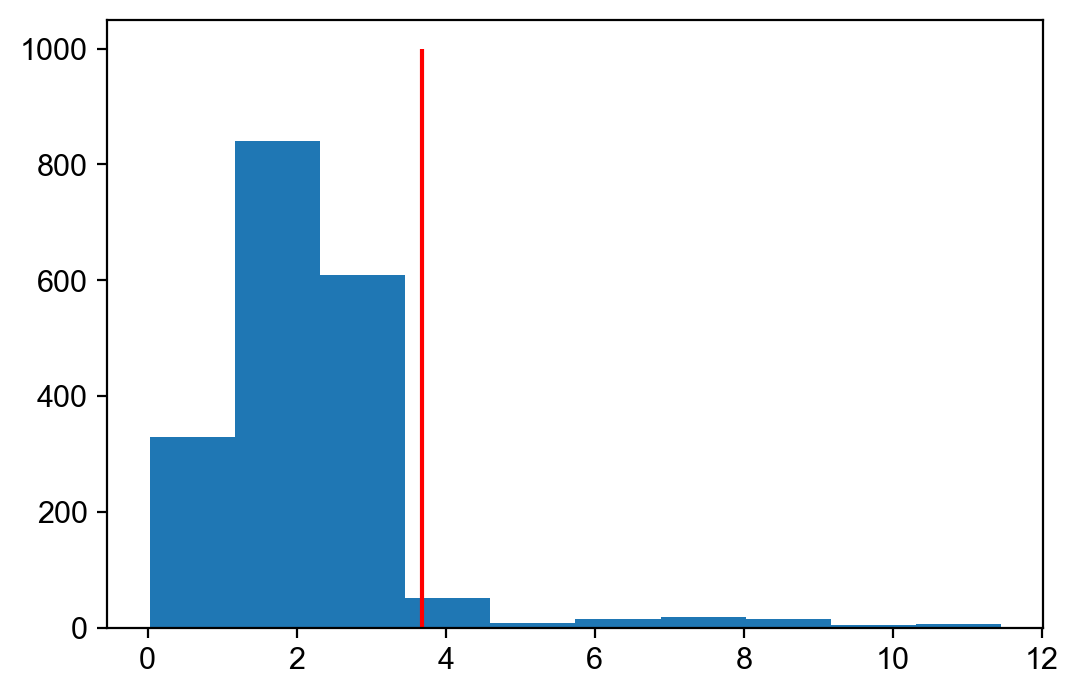

In [53]:
plt.figure()
plt.hist(np.array([i for i in distances.values()]))
plt.vlines(x=cut, ymin=0, ymax=1000, colors="red")
plt.show()

In [60]:
for tf in tfs:

    hi_mask = (velo_df["celltype_adj"] == "MPP") & (velo_df[tf] == "high")
    lo_mask = (velo_df["celltype_adj"] == "MPP") & (velo_df[tf] == "low")

    X_avg_hi = np.mean(velo_df.loc[hi_mask, "x"])
    Y_avg_hi = np.mean(velo_df.loc[hi_mask, "y"])

    X_avg_lo = np.mean(velo_df.loc[lo_mask, "x"])
    Y_avg_lo = np.mean(velo_df.loc[lo_mask, "y"])

    vx_avg_hi = np.mean(velo_df.loc[hi_mask, "vx"])
    vy_avg_hi = np.mean(velo_df.loc[hi_mask, "vy"])

    vx_avg_lo = np.mean(velo_df.loc[lo_mask, "vx"])
    vy_avg_lo = np.mean(velo_df.loc[lo_mask, "vy"])

    plt.figure(figsize=(8, 8))

    plt.scatter(mpp_subset["x"], mpp_subset["y"], alpha=0.5, c="green", label="MPP")
    plt.scatter(non_mpp_subset["x"], non_mpp_subset["y"], alpha=0.5, c="lightgrey", label="non-MPP")

    plt.quiver(velo_df["x"], velo_df["y"], velo_df["vx"], velo_df["vy"], 
            angles='xy', scale_units='xy', scale=0.1, 
            color='gray', alpha=0.8, label='Individual Arrows')

    plt.quiver(X_avg_hi, Y_avg_hi, vx_avg_hi, vy_avg_hi, 
            angles='xy', scale_units='xy', scale=0.01, 
            color='red', width=0.01, label=f'{tf} High Avg')

    plt.quiver(X_avg_lo, Y_avg_lo, vx_avg_lo, vy_avg_lo, 
            angles='xy', scale_units='xy', scale=0.01, 
            color='blue', width=0.01, label=f'{tf} Low Avg')

    plt.legend()
    plt.title(f"Comparison of avg velocity by TF accessibility quantile")
    plt.savefig(rf"{python_data_dir}\multivelo_comparison\avg_velo\{tf}.png")
    plt.close()

## Computing pairwise differences in angles (spliced velocity)
First a little test using only the Hoxa9 hi/lo mask, before running it across all genes that are present both in the chromVAR z-scores and the ATAC data used by MultiVelo

In [61]:
hi_mask_hoxa9 = (velo_df["celltype_adj"] == "MPP") & (velo_df["HOXA9"] == "high")
lo_mask_hoxa9 = (velo_df["celltype_adj"] == "MPP") & (velo_df["HOXA9"] == "low")

In [ ]:
hi_set = velo_df.loc[hi_mask_hoxa9, ["x", "y"]]
lo_set = velo_df.loc[lo_mask_hoxa9, ["x", "y"]]

cost_matrix = cdist(hi_set, lo_set, metric='euclidean')

In [109]:
row_ind, col_ind = linear_sum_assignment(cost_matrix)

In [111]:
pairs_df = pd.DataFrame(
    {
        "partner_hi": hi_set.index[row_ind],
        "partner_lo": lo_set.index[col_ind],
    }
)

In [62]:
def unit_vector(vector):
    """ Returns the unit vector of the vector.  """
    return vector / np.linalg.norm(vector)

def angle_between(v1, v2):
    """ Returns the angle in radians between vectors 'v1' and 'v2'::

            >>> angle_between((1, 0, 0), (0, 1, 0))
            1.5707963267948966
            >>> angle_between((1, 0, 0), (1, 0, 0))
            0.0
            >>> angle_between((1, 0, 0), (-1, 0, 0))
            3.141592653589793
    """
    v1_u = unit_vector(v1)
    v2_u = unit_vector(v2)
    return np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0))

In [63]:
z_map = {name.lower().capitalize(): name for name in z_scores.var_names.values}

intersect_genes = [(z_map[gene], gene) for gene in adata_atac.var_names.values if gene in z_map]

In [14]:
intersect_genes

[('Ar', 'Ar'),
 ('BACH2', 'Bach2'),
 ('CLOCK', 'Clock'),
 ('ELK3', 'Elk3'),
 ('ESR1', 'Esr1'),
 ('ETS1', 'Ets1'),
 ('FOXN3', 'Foxn3'),
 ('Foxo1', 'Foxo1'),
 ('GATA2', 'Gata2'),
 ('GFI1', 'Gfi1'),
 ('Gfi1b', 'Gfi1b'),
 ('HLF', 'Hlf'),
 ('HOXA7', 'Hoxa7'),
 ('HOXA9', 'Hoxa9'),
 ('IRF2', 'Irf2'),
 ('IRF8', 'Irf8'),
 ('KLF10', 'Klf10'),
 ('Klf12', 'Klf12'),
 ('KLF6', 'Klf6'),
 ('Mecom', 'Mecom'),
 ('MEF2A', 'Mef2a'),
 ('MEF2C', 'Mef2c'),
 ('MEIS1', 'Meis1'),
 ('MITF', 'Mitf'),
 ('MYCN', 'Mycn'),
 ('NFAT5', 'Nfat5'),
 ('NFATC1', 'Nfatc1'),
 ('NFATC2', 'Nfatc2'),
 ('NFE2', 'Nfe2'),
 ('NFIA', 'Nfia'),
 ('NR1D2', 'Nr1d2'),
 ('PBX1', 'Pbx1'),
 ('PBX3', 'Pbx3'),
 ('POU2F1', 'Pou2f1'),
 ('POU2F2', 'Pou2f2'),
 ('REL', 'Rel'),
 ('RFX3', 'Rfx3'),
 ('RORA', 'Rora'),
 ('RUNX2', 'Runx2'),
 ('SMAD3', 'Smad3'),
 ('Sox6', 'Sox6'),
 ('SP4', 'Sp4'),
 ('SREBF2', 'Srebf2'),
 ('STAT1', 'Stat1'),
 ('STAT3', 'Stat3'),
 ('Stat4', 'Stat4'),
 ('TCF7L2', 'Tcf7l2'),
 ('TFAP4', 'Tfap4'),
 ('ZEB1', 'Zeb1')]

In [ ]:
angle_data = {}

for gene_z, gene_atac in intersect_genes:

    gene_data = z_scores[:, gene_z].X.flatten()

    labels = pd.qcut(
        gene_data,
        q=[0, 0.25, 0.75, 1.0],  
        labels=["low", "med", "high"],
    )

    velo_df[gene_atac] = pd.Series(labels, index=z_scores.obs_names).reindex(mv_data.obs_names)
    
    hi_mask_gene = (velo_df["celltype_adj"] == "MPP") & (velo_df[gene_atac] == "high")
    lo_mask_gene = (velo_df["celltype_adj"] == "MPP") & (velo_df[gene_atac] == "low")

    hi_set = velo_df.loc[hi_mask_gene, ["x", "y"]]
    lo_set = velo_df.loc[lo_mask_gene, ["x", "y"]]

    cost_matrix = cdist(hi_set, lo_set, metric='euclidean')
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    pairs_df = pd.DataFrame(
        {
            "partner_hi": hi_set.index[row_ind],
            "partner_lo": lo_set.index[col_ind],
        }
    )

    angles = []

    for _, row in pairs_df.iterrows():
        angle = angle_between(
            np.array([velo_df.loc[row["partner_hi"], "vx"], velo_df.loc[row["partner_hi"], "vy"]]),
            np.array([velo_df.loc[row["partner_lo"], "vx"], velo_df.loc[row["partner_lo"], "vy"]])
        )
        angles.append(angle)

    angle_data[gene_atac] = {
        "angles": angles,
        "angle": np.mean(angles),
        "num_pairs": len(angles)
    }

    velo_df.drop(columns=gene_atac, inplace=True)

Ar
512
Bach2
334
Clock
385
Elk3
345
Esr1
481
Ets1
411
Foxn3
320
Foxo1
475
Gata2
71
Gfi1
675
Gfi1b
809
Hlf
134
Hoxa7
325
Hoxa9
435
Irf2
426
Irf8
448
Klf10
197
Klf12
108
Klf6
115
Mecom
117
Mef2a
710
Mef2c
718
Meis1
457
Mitf
387
Mycn
297
Nfat5
387
Nfatc1
406
Nfatc2
303
Nfe2
300
Nfia
463
Nr1d2
451
Pbx1
682
Pbx3
534
Pou2f1
367
Pou2f2
424
Rel
444
Rfx3
561
Rora
388
Runx2
660
Smad3
354
Sox6
530
Sp4
220
Srebf2
534
Stat1
453
Stat3
403
Stat4
536
Tcf7l2
677
Tfap4
640
Zeb1
793


In [65]:
fig, axes = plt.subplots(
    nrows=len(angle_data),
    ncols=1,
    figsize=(6, 3 * len(angle_data)),
    squeeze=False
)

for ax, (gene, data) in zip(axes[:, 0], angle_data.items()):
    ax.hist(data["angles"], bins=30)
    ax.set_title(gene)
    ax.set_xlabel("Angle difference")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x000002217DDA3C70> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

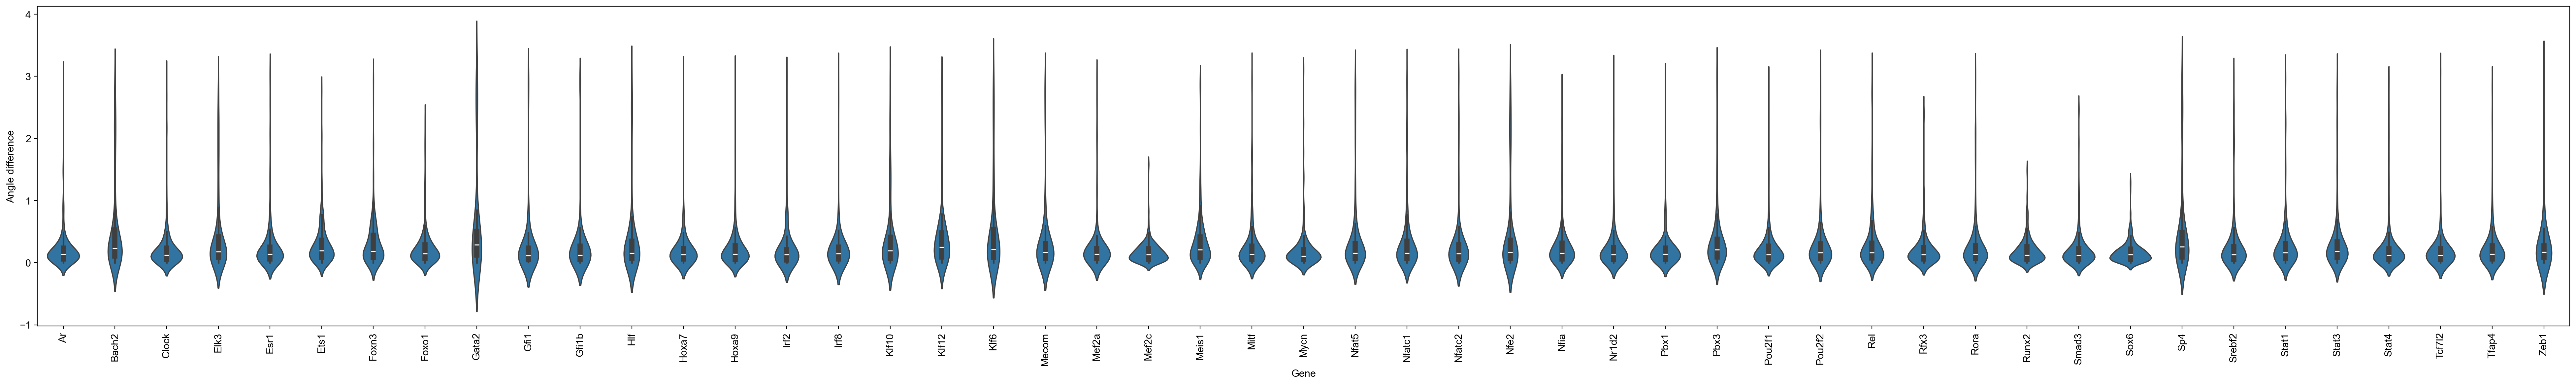

In [73]:
import seaborn as sns

plot_df = pd.DataFrame(
    [(gene, angle) for gene, data in angle_data.items() for angle in data["angles"]],
    columns=["gene", "angle"]
)

plt.figure(figsize=(max(8, len(angle_data) * 0.8), 6))
sns.violinplot(data=plot_df, x="gene", y="angle", inner="box")
plt.xticks(rotation=90)
plt.xlabel("Gene")
plt.ylabel("Angle difference")
plt.tight_layout()
plt.show()

## Computing pairwise differences in velocities (unspliced velocities)

        Consider computing the graph in an unbiased manner 
        on full expression space by not specifying basis.

computing velocity graph (using 1/8 cores)


  0%|          | 0/5241 [00:00<?, ?cells/s]

    finished (0:00:44) --> added 
    'velo_u_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:03) --> added
    'velo_u_norm_umap', embedded velocity vectors (adata.obsm)


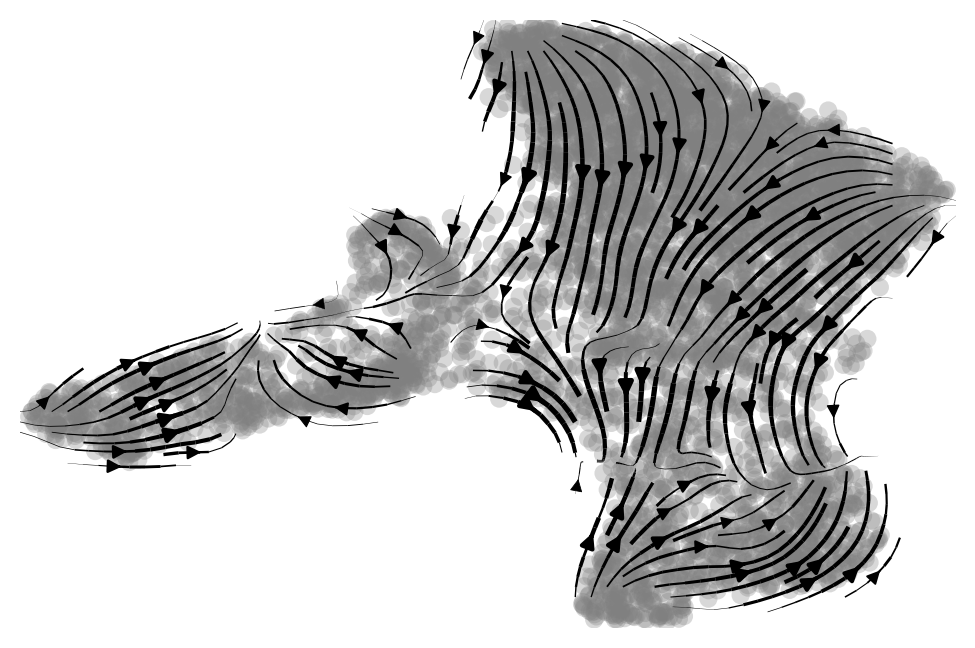

In [74]:
mv.velocity_embedding_stream(mv_data, vkey="velo_u", basis='umap')

In [75]:
# umap_velos_u = mv_data.obsm["velo_u_norm_umap"]
# velo_df_u = pd.DataFrame(umap_velos_u, index=mv_data.obs_names.values)
# velo_df_u.rename(columns={0:"vx", 1:"vy"}, inplace=True)
# velo_df_u.index.rename("cell", inplace=True)
# velo_df_u["celltype"] = mv_data.obs["celltype"]
# velo_df_u[["x", "y"]] = mv_data.obsm["X_umap"]

# for tf in tfs:
#     velo_df_u[tf] = mv_data.obs[f"{tf}_zscore"]

# velo_df_u = adjust_mpp(velo_df_u)

velo_df_u = velo_df.copy()
velo_df_u[["vx", "vy"]] = mv_data.obsm["velo_u_norm_umap"]

In [76]:
angle_data = {}

for gene_z, gene_atac in intersect_genes:

    gene_data = z_scores[:, gene_z].X.flatten()

    labels = pd.qcut(
        gene_data,
        q=[0, 0.25, 0.75, 1.0],  
        labels=["low", "med", "high"],
    )

    velo_df_u[gene_atac] = pd.Series(labels, index=z_scores.obs_names).reindex(mv_data.obs_names)
    
    hi_mask_gene = (velo_df_u["celltype_adj"] == "MPP") & (velo_df_u[gene_atac] == "high")
    lo_mask_gene = (velo_df_u["celltype_adj"] == "MPP") & (velo_df_u[gene_atac] == "low")


    hi_set = velo_df_u.loc[hi_mask_gene, ["x", "y"]]
    lo_set = velo_df_u.loc[lo_mask_gene, ["x", "y"]]

    cost_matrix = cdist(hi_set, lo_set, metric='euclidean')
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    pairs_df = pd.DataFrame(
        {
            "partner_hi": hi_set.index[row_ind],
            "partner_lo": lo_set.index[col_ind],
        }
    )

    angles = []

    for _, row in pairs_df.iterrows():
        angle = angle_between(
            np.array([velo_df_u.loc[row["partner_hi"], "vx"], velo_df_u.loc[row["partner_hi"], "vy"]]),
            np.array([velo_df_u.loc[row["partner_lo"], "vx"], velo_df_u.loc[row["partner_lo"], "vy"]])
        )
        angles.append(angle)

    angle_data[gene_atac] = {
        "angles": angles,
        "angle": np.mean(angles),
        "num_pairs": len(angles)
    }

    velo_df_u.drop(columns=gene_atac, inplace=True)

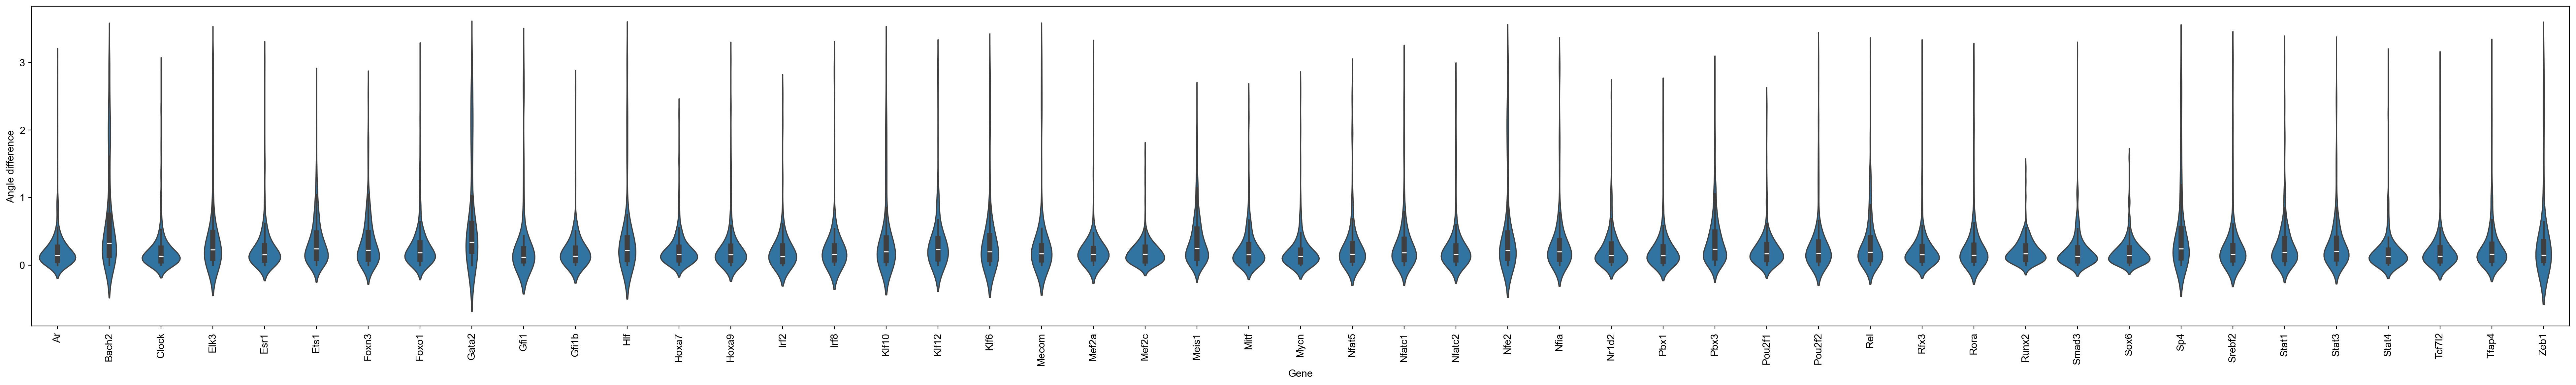

In [77]:
plot_df = pd.DataFrame(
    [(gene, angle) for gene, data in angle_data.items() for angle in data["angles"]],
    columns=["gene", "angle"]
)

plt.figure(figsize=(max(8, len(angle_data) * 0.8), 6))
sns.violinplot(data=plot_df, x="gene", y="angle", inner="box")
plt.xticks(rotation=90)
plt.xlabel("Gene")
plt.ylabel("Angle difference")
plt.tight_layout()
plt.show()

## Computing pairwise differences in velocities (chrom velocities)

        Consider computing the graph in an unbiased manner 
        on full expression space by not specifying basis.

computing velocity graph (using 1/8 cores)


  0%|          | 0/5241 [00:00<?, ?cells/s]

    finished (0:00:48) --> added 
    'velo_chrom_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:03) --> added
    'velo_chrom_norm_umap', embedded velocity vectors (adata.obsm)


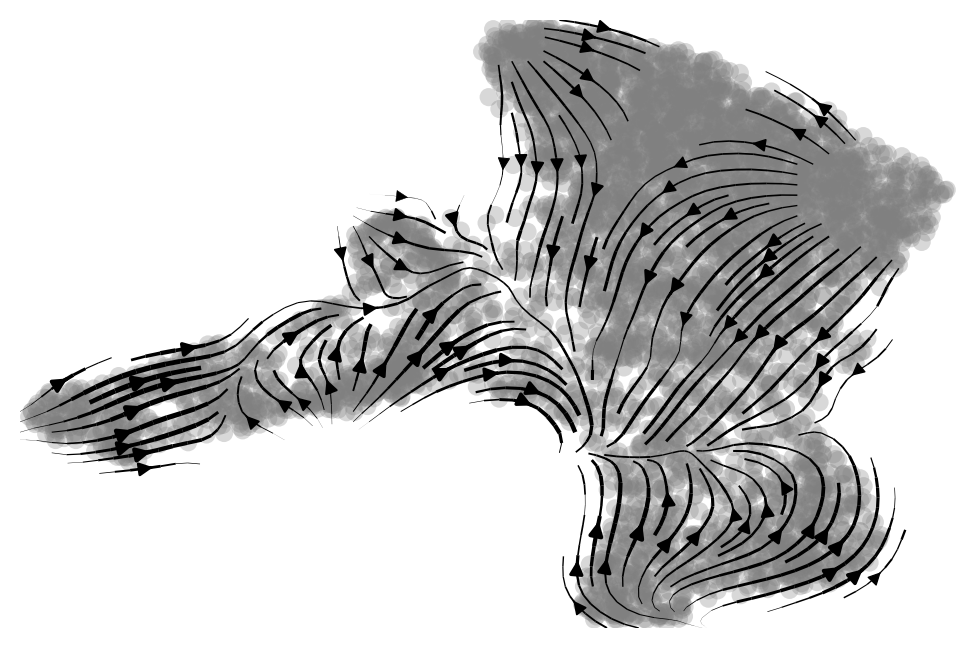

In [78]:
mv.velocity_embedding_stream(mv_data, vkey="velo_chrom", basis='umap')

In [79]:
# umap_velos_c = mv_data.obsm["velo_chrom_norm_umap"]
# velo_df_c = pd.DataFrame(umap_velos_c, index=mv_data.obs_names.values)
# velo_df_c.rename(columns={0:"vx", 1:"vy"}, inplace=True)
# velo_df_c.index.rename("cell", inplace=True)
# velo_df_c["celltype"] = mv_data.obs["celltype"]
# velo_df_c[["x", "y"]] = mv_data.obsm["X_umap"]

# for tf in tfs:
#     velo_df_c[tf] = mv_data.obs[f"{tf}_zscore"]

velo_df_c = velo_df_u.copy()
velo_df_c[["vx", "vy"]] = mv_data.obsm["velo_chrom_norm_umap"]

In [80]:
angle_data = {}

for gene_z, gene_atac in intersect_genes:

    gene_data = z_scores[:, gene_z].X.flatten()

    labels = pd.qcut(
        gene_data,
        q=[0, 0.10, 0.90, 1.0],  
        labels=["low", "med", "high"],
    )

    velo_df_c[gene_atac] = pd.Series(labels, index=z_scores.obs_names).reindex(mv_data.obs_names)
    
    hi_mask_gene = (velo_df_c["celltype_adj"] == "MPP") & (velo_df_c[gene_atac] == "high")
    lo_mask_gene = (velo_df_c["celltype_adj"] == "MPP") & (velo_df_c[gene_atac] == "low")


    hi_set = velo_df_c.loc[hi_mask_gene, ["x", "y"]]
    lo_set = velo_df_c.loc[lo_mask_gene, ["x", "y"]]

    cost_matrix = cdist(hi_set, lo_set, metric='euclidean')
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    pairs_df = pd.DataFrame(
        {
            "partner_hi": hi_set.index[row_ind],
            "partner_lo": lo_set.index[col_ind],
        }
    )

    angles = []

    for _, row in pairs_df.iterrows():
        angle = angle_between(
            np.array([velo_df_c.loc[row["partner_hi"], "vx"], velo_df_c.loc[row["partner_hi"], "vy"]]),
            np.array([velo_df_c.loc[row["partner_lo"], "vx"], velo_df_c.loc[row["partner_lo"], "vy"]])
        )
        angles.append(angle)

    angle_data[gene_atac] = {
        "angles": angles,
        "angle": np.mean(angles),
        "num_pairs": len(angles)
    }

    velo_df_c.drop(columns=gene_atac, inplace=True)

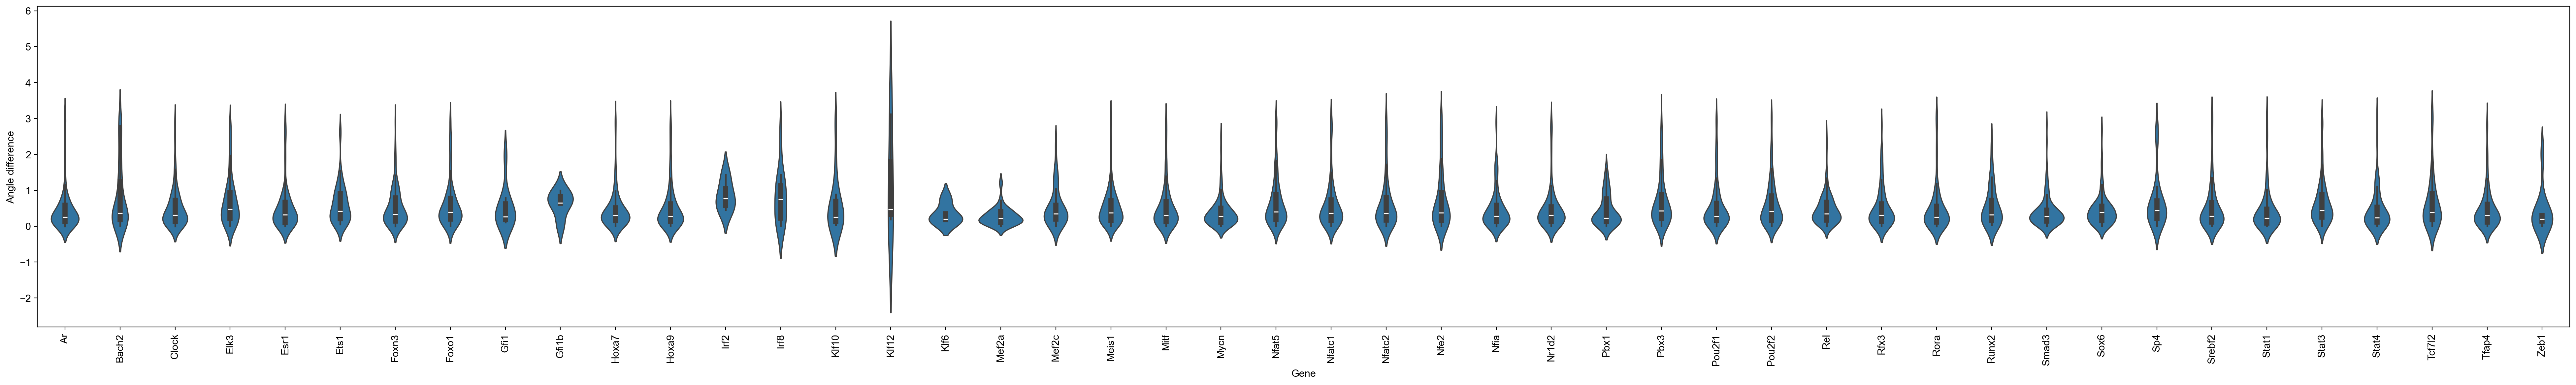

In [81]:
plot_df = pd.DataFrame(
    [(gene, angle) for gene, data in angle_data.items() for angle in data["angles"]],
    columns=["gene", "angle"]
)

plt.figure(figsize=(max(8, len(angle_data) * 0.8), 6))
sns.violinplot(data=plot_df, x="gene", y="angle", inner="box")
plt.xticks(rotation=90)
plt.xlabel("Gene")
plt.ylabel("Angle difference")
plt.tight_layout()
plt.show()

## Comparing absolute velocities of different groups
Instead of checking if there are differences in the direction of development, check if one group of cells is experiencing a stronger "push" towards differentiation.

In [82]:
def vec_diff(v1, v2):
    diff = np.linalg.norm(v1)-np.linalg.norm(v2)  # This is signed!
    return diff

In [83]:
push_data = {}

for gene_z, gene_atac in intersect_genes:

    gene_data = z_scores[:, gene_z].X.flatten()

    labels = pd.qcut(
        gene_data,
        q=[0, 0.25, 0.75, 1.0],  
        labels=["low", "med", "high"],
    )

    velo_df[gene_atac] = pd.Series(labels, index=z_scores.obs_names).reindex(mv_data.obs_names)
    
    hi_mask_gene = (velo_df["celltype_adj"] == "MPP") & (velo_df[gene_atac] == "high")
    lo_mask_gene = (velo_df["celltype_adj"] == "MPP") & (velo_df[gene_atac] == "low")


    hi_set = velo_df.loc[hi_mask_gene, ["x", "y"]]
    lo_set = velo_df.loc[lo_mask_gene, ["x", "y"]]

    cost_matrix = cdist(hi_set, lo_set, metric='euclidean')
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    pairs_df = pd.DataFrame(
        {
            "partner_hi": hi_set.index[row_ind],
            "partner_lo": lo_set.index[col_ind],
        }
    )

    diff_vals = []

    for _, row in pairs_df.iterrows():
        diff = vec_diff(
            np.array([velo_df.loc[row["partner_hi"], "vx"], velo_df.loc[row["partner_hi"], "vy"]]),
            np.array([velo_df.loc[row["partner_lo"], "vx"], velo_df.loc[row["partner_lo"], "vy"]])
        ) # This is a signed difference. The "assumption" is that high accessibility corresponds with a higher velocity
        diff_vals.append(diff)

    push_data[gene_atac] = {
        "diffs": diff_vals,
        "num_pairs": len(diff_vals)
    }

    velo_df.drop(columns=gene_atac, inplace=True)

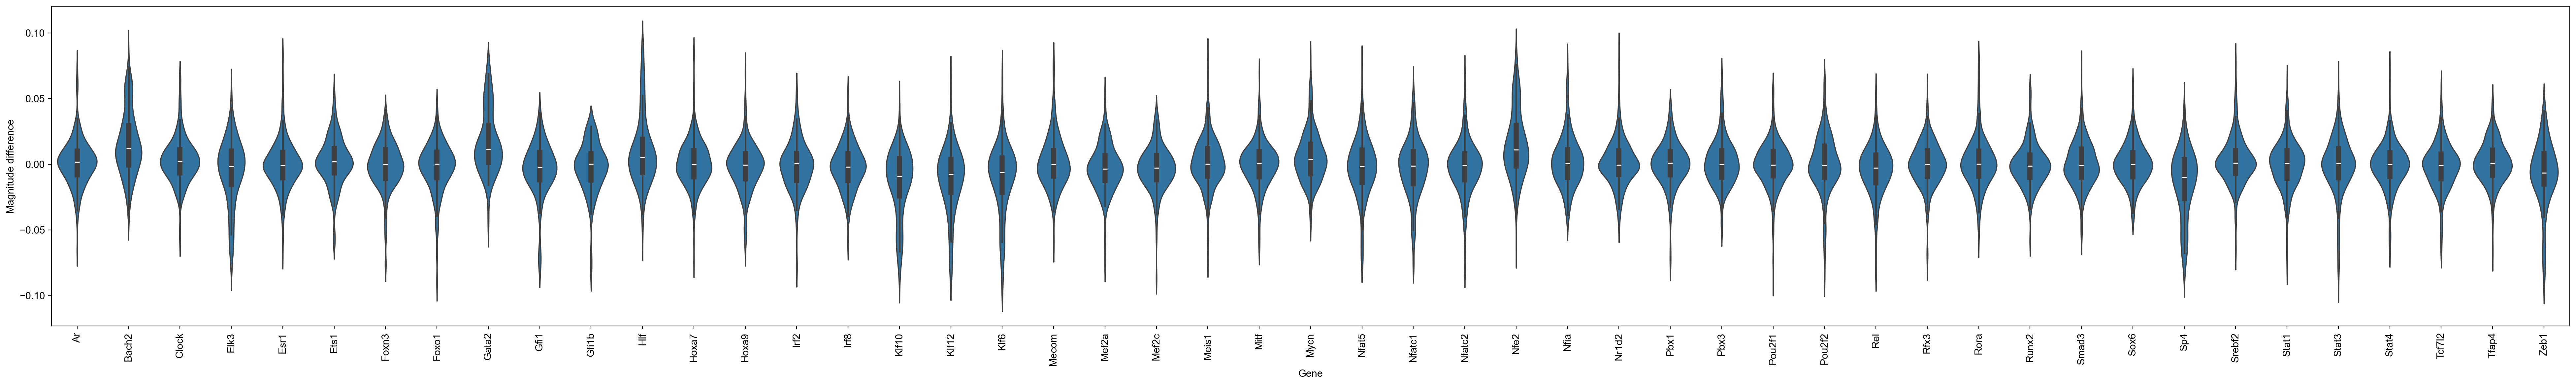

In [84]:
plot_df = pd.DataFrame(
    [(gene, diff) for gene, data in push_data.items() for diff in data["diffs"]],
    columns=["gene", "diff"]
)

plt.figure(figsize=(max(8, len(push_data) * 0.8), 6))
sns.violinplot(data=plot_df, x="gene", y="diff", inner="box")
plt.xticks(rotation=90)
plt.xlabel("Gene")
plt.ylabel("Magnitude difference")
plt.tight_layout()
plt.show()

# Gata2, Hlf, Mecom, Nfe2 look interesting

In [85]:
more_tfs = ["GATA2", "HLF", "Mecom", "NFE2"]

for i, tf in enumerate(more_tfs): 

    tf_data = z_scores[:, tf].X.flatten()

    labels = pd.qcut(
        tf_data,
        q=[0, 0.10, 0.90, 1.0],  
        labels=["low", "med", "high"],
    )

    mv_data.obs[f"{tf}_zscore"] = pd.Series(labels, index=z_scores.obs_names).reindex(mv_data.obs_names)

In [86]:
# umap_velos = mv_data.obsm["velo_s_norm_umap"]
# velo_df = pd.DataFrame(umap_velos, index=mv_data.obs_names.values)
# velo_df.rename(columns={0:"vx", 1:"vy"}, inplace=True)
# velo_df.index.rename("cell", inplace=True)
# velo_df["celltype"] = mv_data.obs["celltype"]
# velo_df[["x", "y"]] = mv_data.obsm["X_umap"]

for tf in more_tfs:
    velo_df[tf] = mv_data.obs[f"{tf}_zscore"]

In [87]:
mpp_subset = velo_df[velo_df["celltype_adj"] == "MPP"]
non_mpp_subset = velo_df[velo_df["celltype_adj"] != "MPP"]

for tf in more_tfs:

    hi_mask = (velo_df["celltype_adj"] == "MPP") & (velo_df[tf] == "high")
    lo_mask = (velo_df["celltype_adj"] == "MPP") & (velo_df[tf] == "low")

    hi = velo_df.loc[hi_mask,:]
    lo = velo_df.loc[lo_mask,:]

    plt.figure(figsize=(8, 8))

    plt.scatter(mpp_subset["x"], mpp_subset["y"], alpha=0.5, c="orange", label="MPP")
    plt.scatter(non_mpp_subset["x"], non_mpp_subset["y"], alpha=0.5, c="lightgrey", label="non-MPP")

    plt.quiver(hi["x"], hi["y"], hi["vx"], hi["vy"], 
            angles='xy', scale_units='xy', scale=0.1, 
            color='red', alpha=0.8, label='Individual Arrows')

    plt.quiver(lo["x"], lo["y"], lo["vx"], lo["vy"], 
                angles='xy', scale_units='xy', scale=0.1, 
                color='blue', alpha=0.8, label='Individual Arrows')

    plt.legend()
    plt.title(f"Comparison of avg velocity by TF accessibility quantile")
    plt.savefig(rf"{python_data_dir}\multivelo_comparison\abs_diff\{tf}.png")
    plt.close()